In [38]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt

In [75]:
df = pd.read_csv("master.csv")
df["Date"] = pd.to_datetime(df["Date"], utc=True)
df.head()

,Date,log_return,mkt_return,tsla_volume,mkt_volume,tsla_wiki_views,tsla_edits,tsla_unique_editors,msk_wiki_views,msk_edits,msk_unique_editors,msk_tweets
0,2017-02-06 05:00:00+00:00,0.025301,-0.002118,53437500,3112390000,2224,2.0,2.0,25707,1.0,1.0,14.0
1,2017-02-07 05:00:00+00:00,-0.001126,0.000227,63672000,3452460000,2476,0.0,0.0,27886,0.0,0.0,1.0
2,2017-02-08 05:00:00+00:00,0.017708,0.000693,58995000,3611950000,3432,0.0,0.0,24202,3.0,2.0,5.0
3,2017-02-09 05:00:00+00:00,0.026805,0.005736,117303000,3681600000,4009,1.0,1.0,22390,1.0,1.0,5.0
4,2017-02-10 05:00:00+00:00,0.000111,0.003560,54295500,3496600000,3767,0.0,0.0,20018,2.0,2.0,1.0


In [ ]:
from numpy import log

In [86]:
df.loc[df.index[1585], "mkt_volume"] += 1

df.loc[df.index[1585], "tsla_volume"] += 1


df.iloc[1585]

Date                   2023-05-24 04:00:00+00:00
log_return                              -0.01557
mkt_return                             -0.007346
tsla_volume                            137605101
mkt_volume                                     1
tsla_wiki_views                             7302
tsla_edits                                   0.0
tsla_unique_editors                          0.0
msk_wiki_views                             59200
msk_edits                                    3.0
msk_unique_editors                           3.0
msk_tweets                                  41.0
tsla_views_unex                     -1927.642781
Name: 1585, dtype: object

In [130]:
formula = "log_return ~ mkt_return + np.log(mkt_volume) + np.log(tsla_volume) + tsla_edits + tsla_views_unex + msk_tweets + msk_edits + msk_edits.shift(1) + msk_wiki_views"
# formula = "log_return ~ mkt_return + msk_tweets + tsla_edits + msk_edits.shift(1) + tsla_volume"
def regress(a: int):
    global dfc
    dfc = df[df["Date"].dt.year >= a].copy()
    global lm
    lm = smf.ols(formula, data=dfc).fit(cov_type="HC1")
    global lm1
    lm1 = smf.ols(formula + " + tsla_edits.shift(1)", data=dfc).fit(cov_type="HC1")
    print(f"====== Results for year >= a =====")
    print(lm.summary())

interact(regress, a=IntSlider(min=2017, max=2025, step=1, value=2017))


interactive(children=(IntSlider(value=2017, description='a', max=2025, min=2017), Output()), _dom_classes=('wi…

<function __main__.regress(a: int)>

In [ ]:
lm.f_test("msk_edits + msk_edits.shift(1) = 0")

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=2.9632090949347396, p=0.031167521231188017, df_denom=1.32e+03, df_num=3>

In [ ]:
lm.t_test("msk_edits + msk_edits.shift(1) - msk_wiki_views = 0")

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0004      0.000     -2.542      0.011      -0.001   -9.18e-05

In [135]:
lm1.t_test("msk_edits + msk_edits.shift(1) + msk_wiki_views = tsla_edits + tsla_edits.shift(1) + tsla_views_unex")

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0005      0.000     -1.728      0.084      -0.001    6.73e-05

In [123]:
lm.f_test("msk_edits + msk_edits.shift(1) = 0")

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=6.053051190835385, p=0.014010024468744546, df_denom=1.32e+03, df_num=1>

In [108]:
df["msk_edits"].corr(df["msk_edits"].shift(1))

np.float64(0.5440733041466792)

In [ ]:
lm.f_test('msk_edits = msk_edits.shift(1) = 0')

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=5.43710666788978, p=0.019863566790862822, df_denom=1.32e+03, df_num=1>

In [93]:
lm.f_test('msk_tweets = msk_edits = msk_edits.shift(1) = msk_wiki_views = 0')

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=3.9819138548737003, p=0.0031933326667912495, df_denom=2.05e+03, df_num=4>

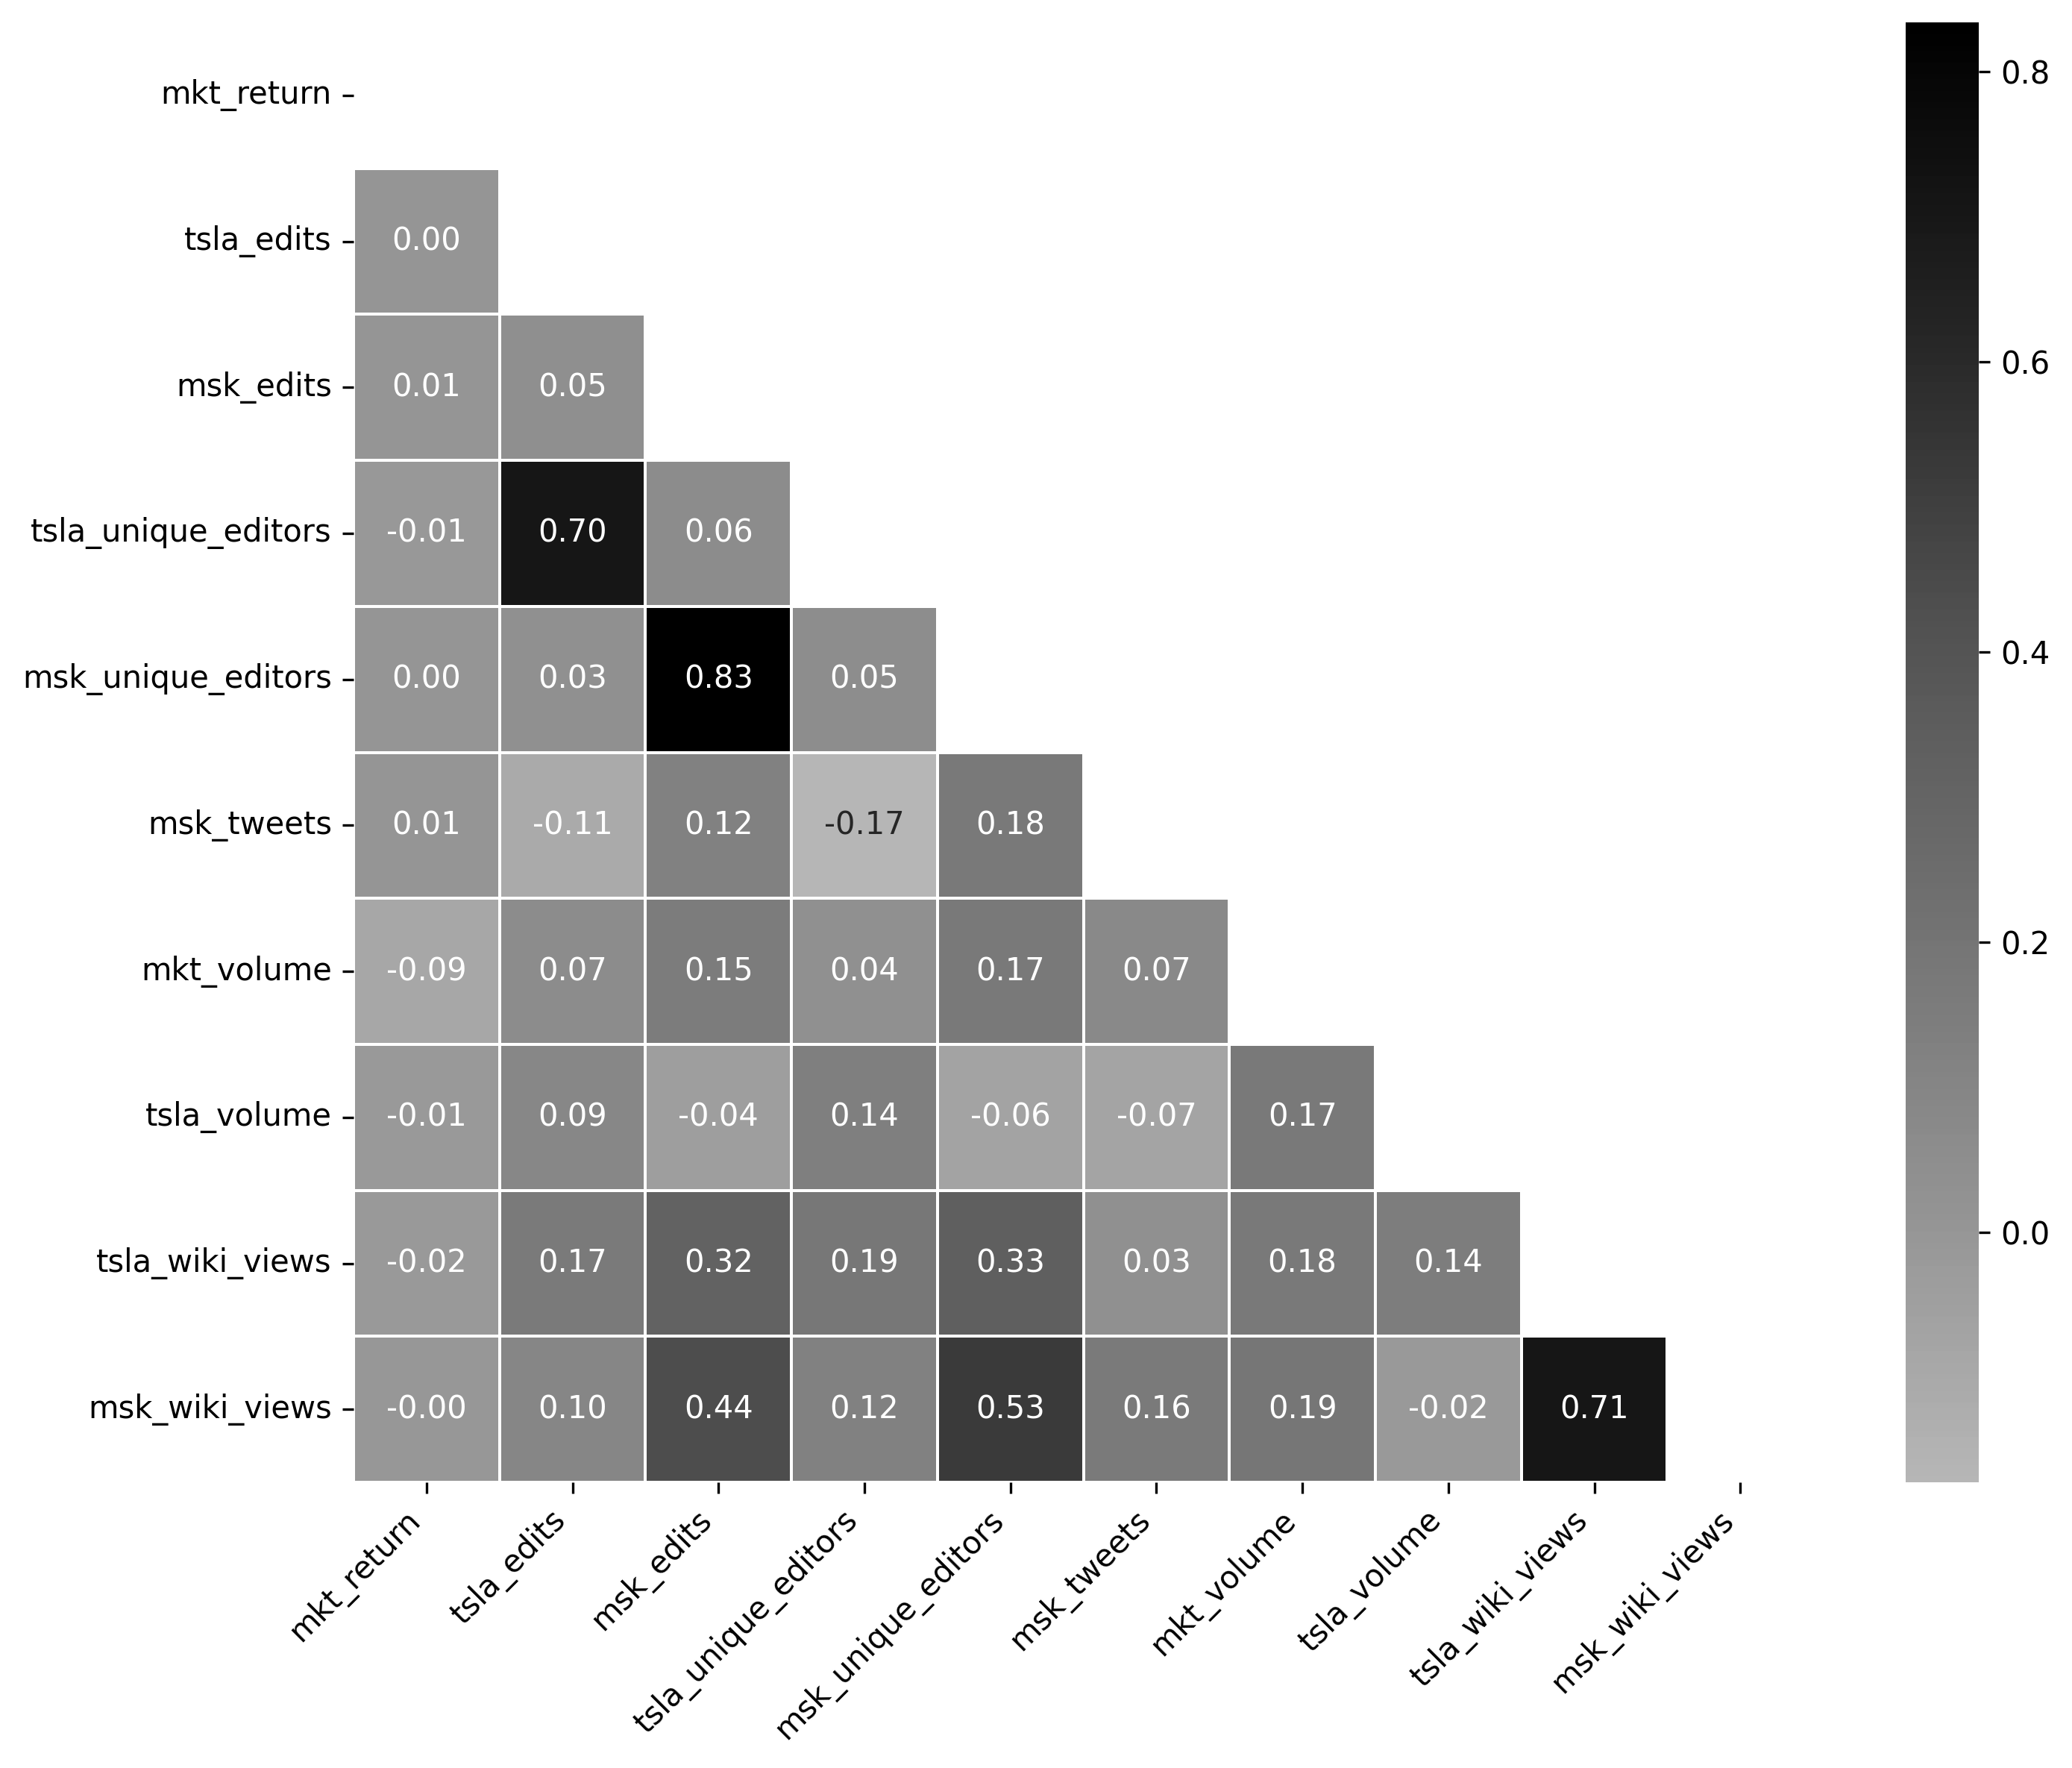

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_predictors = [
    "mkt_return",
    "tsla_edits",
    "msk_edits",
    "tsla_unique_editors",
    "msk_unique_editors",
    "msk_tweets",
    "mkt_volume",
    "tsla_volume",
    "tsla_wiki_views",
    "msk_wiki_views",
]

corr_mat = df[all_predictors].corr()

# mask upper triangle
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

plt.figure(figsize=(10, 8), dpi=300)

sns.heatmap(
    corr_mat,
    mask=mask,
    cmap="Greys",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar=True
)

# plt.title("Correlation Matrix of Predictors", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("correlation_matrix_lower_bw.png", dpi=300, bbox_inches="tight")
plt.show()

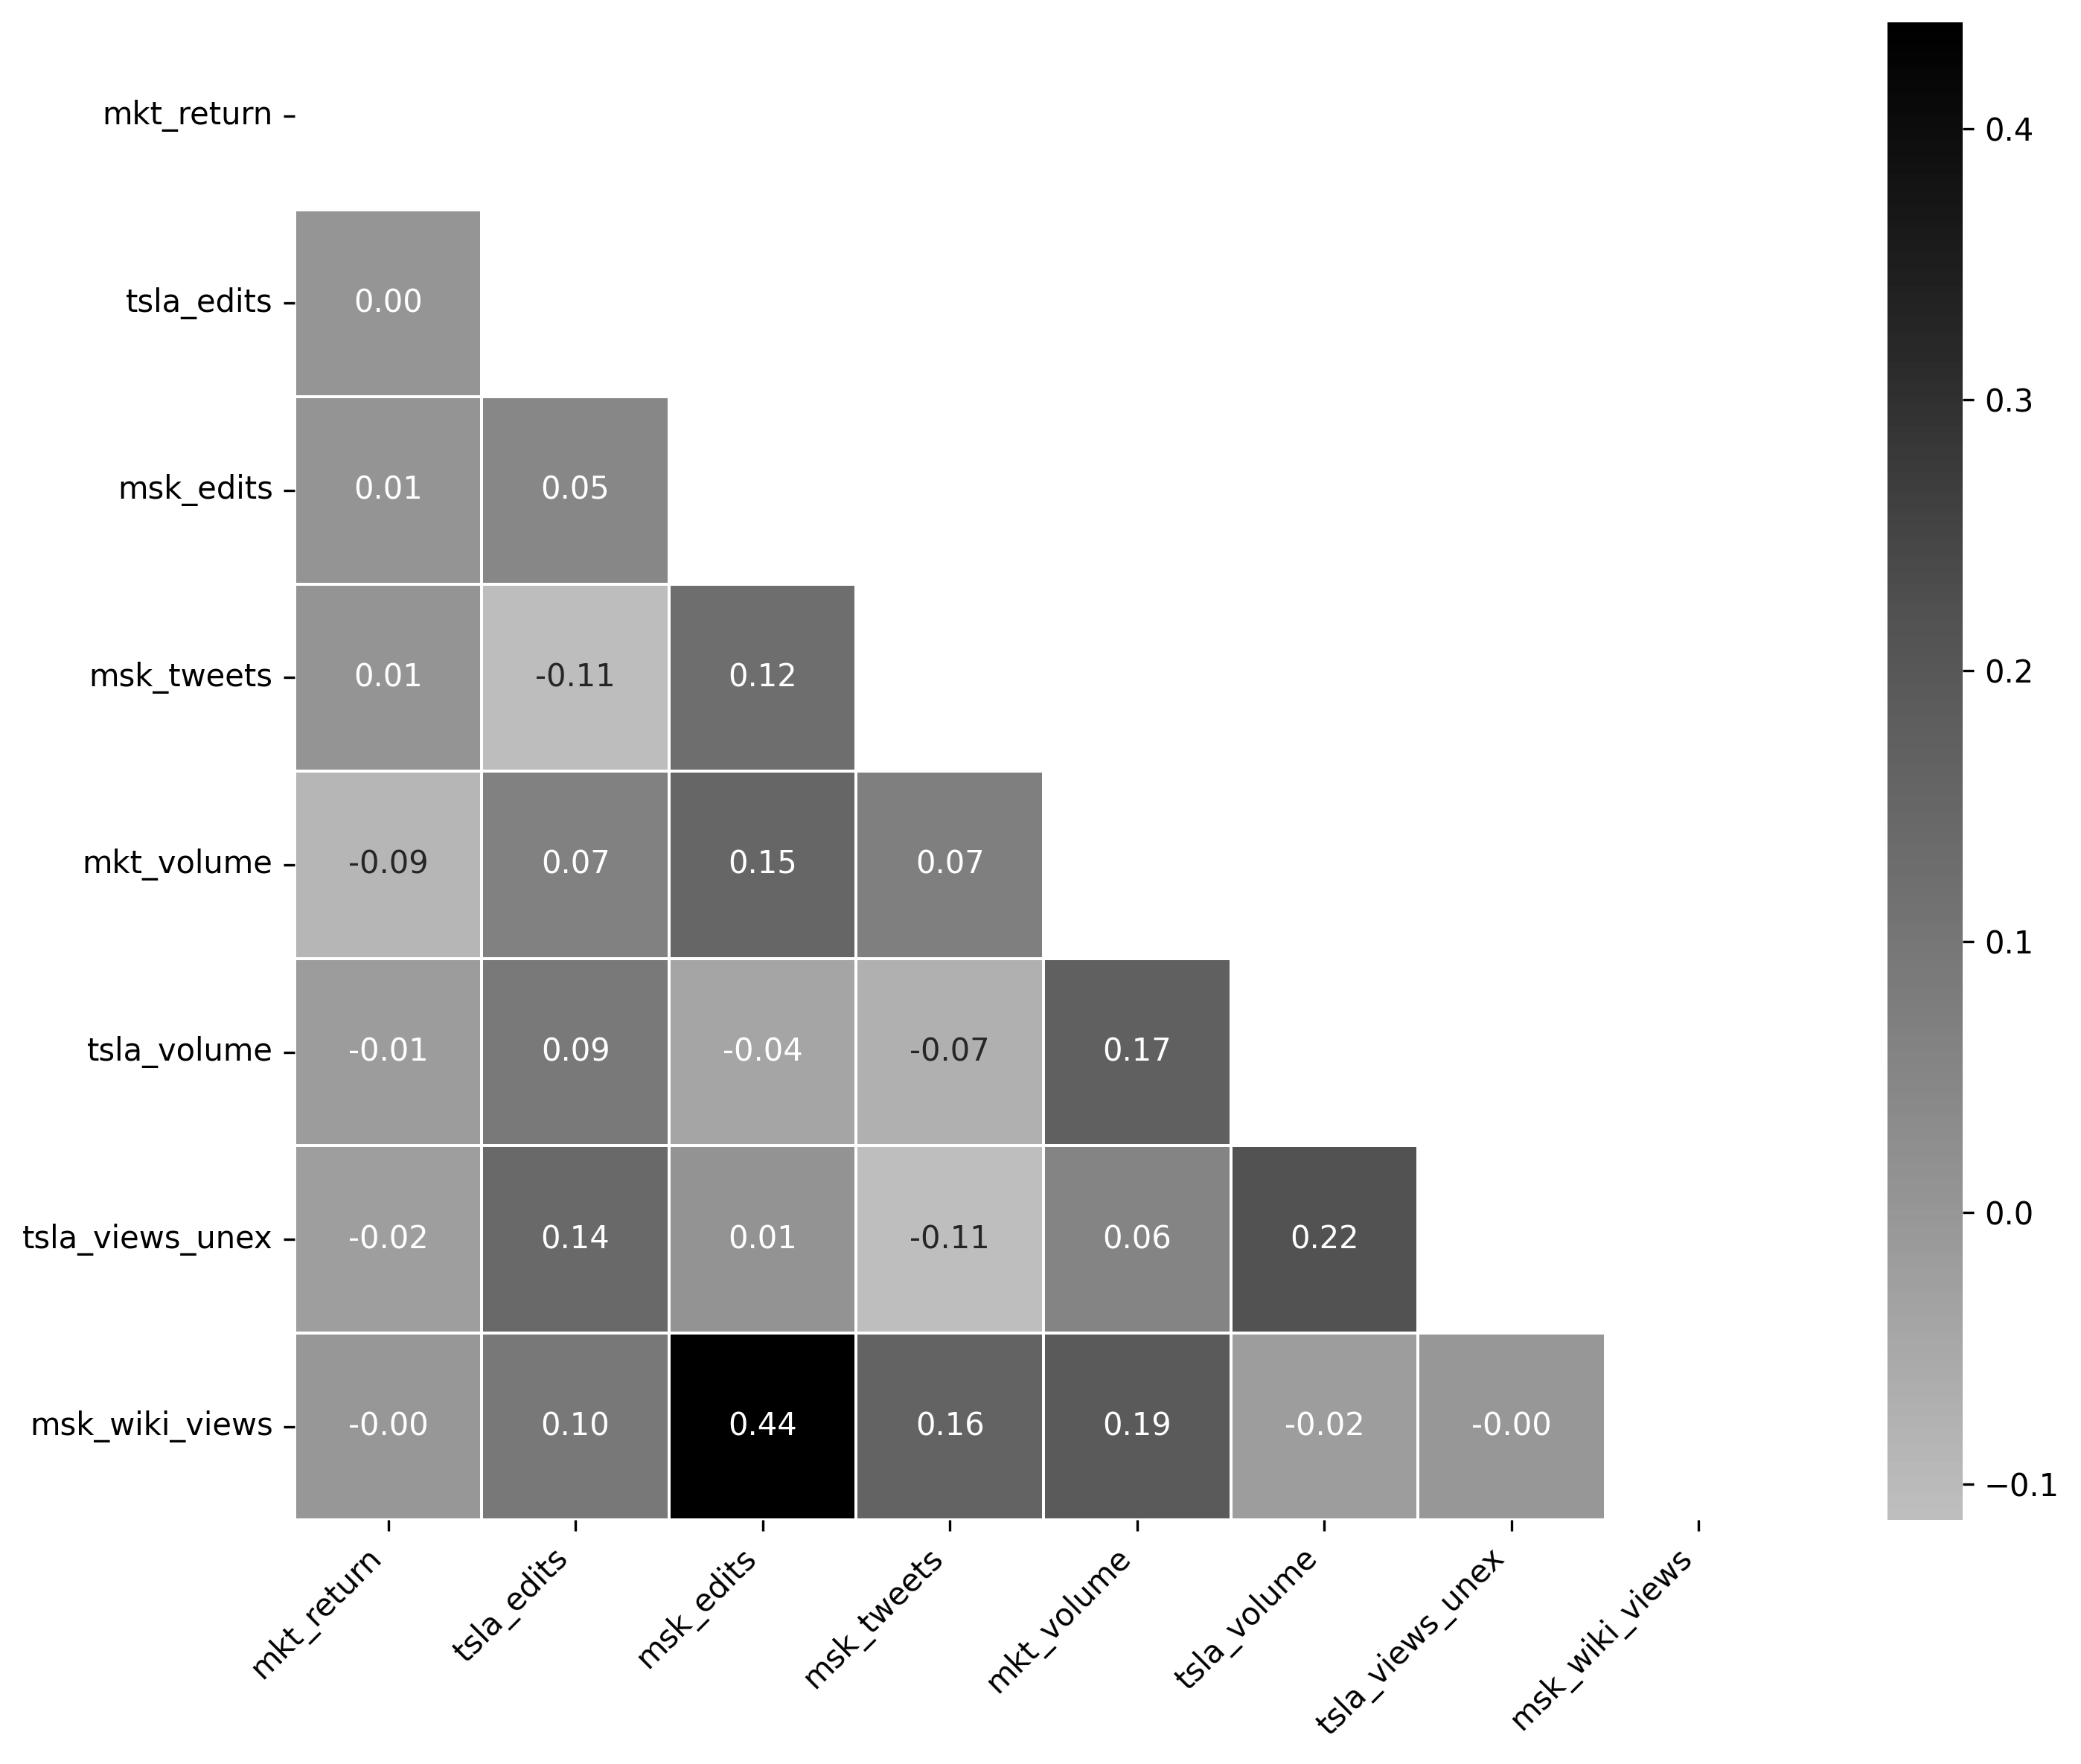

In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_predictors = [
    "mkt_return",
    "tsla_edits",
    "msk_edits",
    "msk_tweets",
    "mkt_volume",
    "tsla_volume",
    "tsla_views_unex",
    "msk_wiki_views"
]

corr_mat = df[all_predictors].corr()

# mask upper triangle
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

plt.figure(figsize=(10, 8), dpi=300)

sns.heatmap(
    corr_mat,
    mask=mask,
    cmap="Greys",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar=True
)

# plt.title("Correlation Matrix of Predictors", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("correlation_matrix_lower_bw.png", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
lmo = smf.ols("tsla_wiki_views ~ msk_wiki_views", data=df).fit()
tsla_views_unex = lmo.resid
df["tsla_views_unex"] = tsla_views_unex

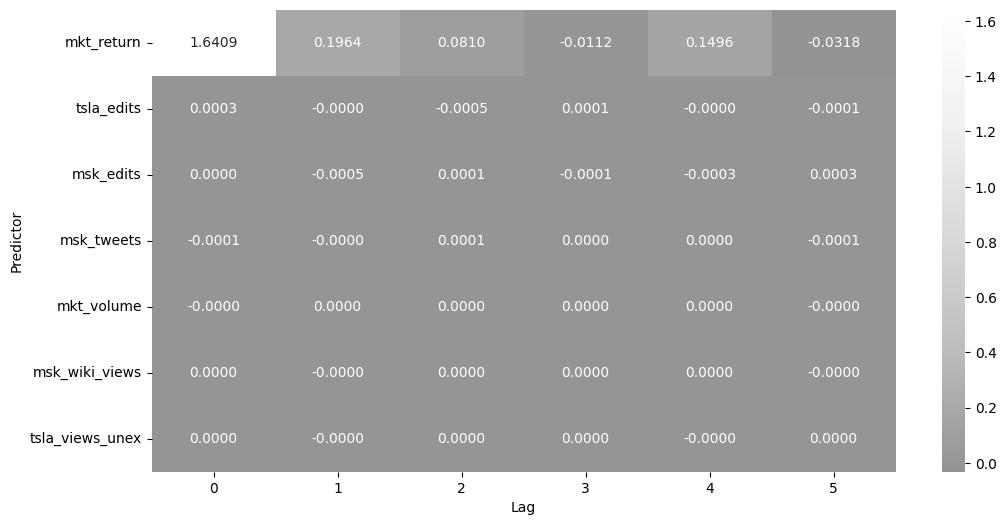

In [71]:

y = df["log_return"]

all_predictors = [
    "mkt_return",
    "tsla_edits",
    "msk_edits",
    "msk_tweets",
    "mkt_volume",
    "msk_wiki_views",
    "tsla_views_unex"
]

plot_predictors = [
    "mkt_return",
    "tsla_edits",
    "msk_edits",
    "msk_tweets",
    "mkt_volume",
    "msk_wiki_views",
    "tsla_views_unex"
]

max_lag = 5

def lag_matrix(x, max_lag):
    return pd.concat(
        {f"lag_{k}": x.shift(k) for k in range(max_lag + 1)},
        axis=1
    )

coef_mat = pd.DataFrame(index=plot_predictors, columns=range(max_lag + 1), dtype=float)

for col in all_predictors:
    X_lags = lag_matrix(df[col], max_lag)

    data = pd.concat([y, X_lags], axis=1).dropna()

    X = sm.add_constant(data.drop(columns=["log_return"]))
    y_reg = data["log_return"]

    model = sm.OLS(y_reg, X).fit()

    # store coefficients (but only if we want to plot them)
    if col in plot_predictors:
        for k in range(max_lag + 1):
            coef_mat.loc[col, k] = model.params[f"lag_{k}"]

plt.figure(figsize=(12, 6))
sns.heatmap(
    coef_mat,
    cmap="Greys_r",
    center=0,
    annot=True,
    fmt=".4f"
)

# plt.title("Distributed Lag Regression Coefficients (mkt_return included but not shown)")
plt.xlabel("Lag")
plt.ylabel("Predictor")
plt.show()

In [50]:
df["tsla_volume"].corr(df["tsla_volume"].shift(1))

np.float64(0.7479296421104897)

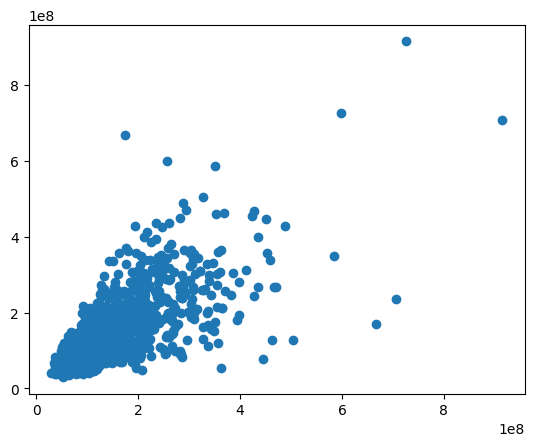

In [51]:
plt.scatter(df["tsla_volume"], df["tsla_volume"].shift(1))